In [2]:
import os
print(os.getcwd())

C:\Users\Lakshmishree\Desktop\Project_01


In [3]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)
df.info()

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [6]:
print(df.duplicated().sum())

0


In [7]:
df['Postal Code'] = df['Postal Code'].astype(str)
df['Postal Code'].dtype

dtype('O')

In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009


In [9]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(category_summary)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


In [10]:
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit')
print(subcat_summary)

                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995
Fasteners       3024.2800    949.5182
Machines      189238.6310   3384.7569
Labels         12486.3120   5546.2540
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Furnishings    91705.1640  13059.1436
Appliances    107532.1610  18138.0054
Storage       223843.6080  21278.8264
Chairs        328449.1030  26590.1663
Binders       203412.7330  30221.7633
Paper          78479.2060  34053.5693
Accessories   167380.3180  41936.6357
Phones        330007.0540  44515.7306
Copiers       149528.0300  55617.8249


In [11]:
discount_check = df.groupby('Sub-Category')[['Discount', 'Profit']].mean().sort_values('Discount', ascending=False)
print(discount_check)

              Discount      Profit
Sub-Category                      
Binders       0.372292   19.843574
Machines      0.306087   29.432669
Tables        0.261285  -55.565771
Bookcases     0.211140  -15.230509
Chairs        0.170178   43.095894
Appliances    0.166524   38.922758
Copiers       0.161765  817.909190
Phones        0.154556   50.073938
Furnishings   0.138349   13.645918
Fasteners     0.082028    4.375660
Envelopes     0.080315   27.418019
Accessories   0.078452   54.111788
Supplies      0.076842   -6.258418
Paper         0.074891   24.856620
Art           0.074874    8.200737
Storage       0.074704   25.152277
Labels        0.068681   15.236962


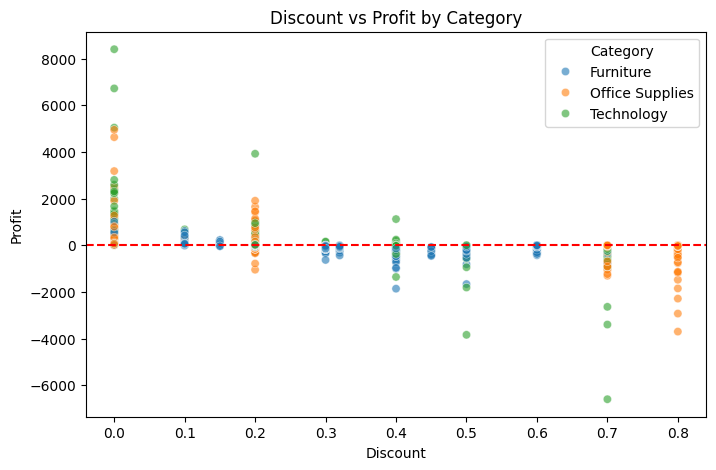

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit by Category')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [13]:
high_discount = df[df['Discount'] >= 0.3]
print(high_discount['Sub-Category'].value_counts())

Sub-Category
Binders        613
Tables         176
Chairs         158
Furnishings    138
Phones         109
Bookcases       70
Appliances      67
Machines        53
Copiers          9
Name: count, dtype: int64


In [14]:
binders = df[df['Sub-Category'] == 'Binders']
print(binders.groupby(binders['Discount'] >= 0.3)['Profit'].mean())

Discount
False    75.529956
True    -62.822996
Name: Profit, dtype: float64


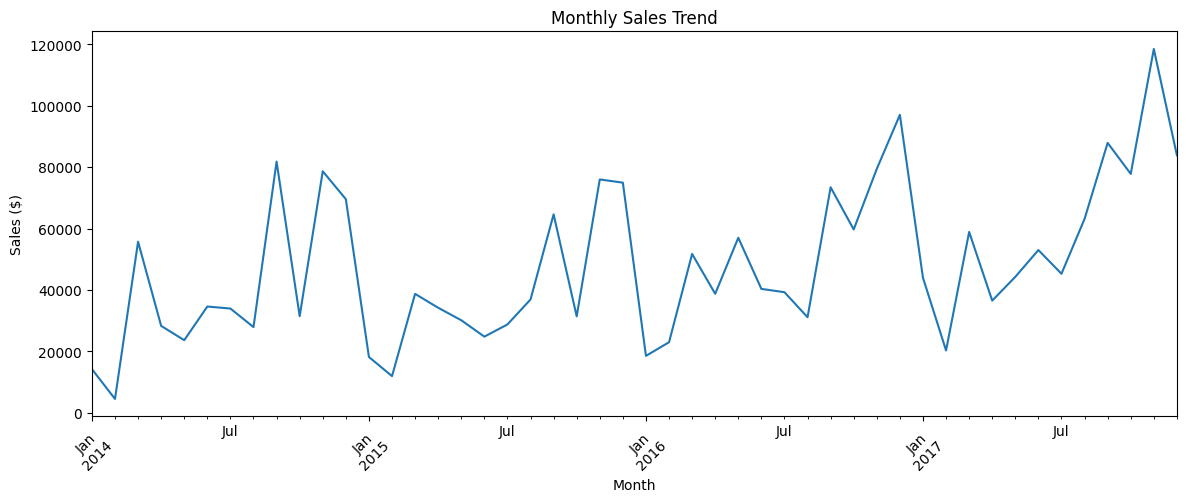

In [15]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

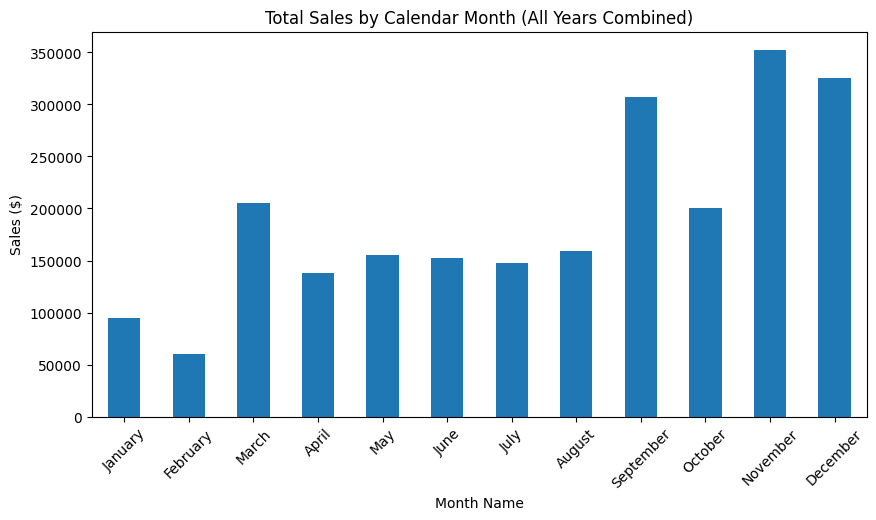

In [16]:
df['Month Name'] = df['Order Date'].dt.month_name()
monthly_avg = df.groupby('Month Name')['Sales'].sum()

# reorder months properly
month_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
monthly_avg = monthly_avg.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title('Total Sales by Calendar Month (All Years Combined)')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

In [17]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(region_summary)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [18]:
region_discount = df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
print(region_discount)

Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64
